In [17]:
import pandas as pd
import numpy as np
import re
import random
import pickle
from itertools import product
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from joblib import Parallel, delayed
from sklearn.metrics import precision_score
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.base import BaseEstimator
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

### Load Dataset

In [2]:
# Load and Prepare Data

ratings_df = pd.read_csv(r"C:\Users\HP\Desktop\Bookify\Database\Cleaned_Datasets\Ratings_Cleaned.csv")
books_df = pd.read_csv(r"C:\Users\HP\Desktop\Bookify\Database\Cleaned_Datasets\Books_Cleaned.csv")

In [3]:
# Clean text function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

# Apply cleaning
books_df['title'] = books_df['title'].apply(clean_text)
books_df['author'] = books_df['author'].apply(clean_text)
books_df['publisher'] = books_df['publisher'].apply(clean_text)

# Create combined field
books_df['combined'] = books_df['title'] + ' ' + books_df['author'] + ' ' + books_df['publisher']

In [4]:
# Encode user_id and book_id as integers for matrix indexing
ratings_df['user_idx'] = ratings_df['user_id'].astype('category').cat.codes
ratings_df['book_idx'] = ratings_df['book_id'].astype('category').cat.codes
ratings_df

,user_id,book_id,ratings,user_idx,book_idx
0,276726,0155061224,5,77180,16882
1,276729,052165615X,3,77181,69139
2,276729,0521795028,6,77181,69159
3,276736,3257224281,8,77182,156888
4,276737,0600570967,6,77183,80250
...,...,...,...,...,...
433666,276704,0806917695,5,77176,111085
433667,276704,1563526298,9,77176,137773
433668,276709,0515107662,10,77177,67144
433669,276721,0590442449,10,77178,78608


## 1. Identify Tunable Parameters & grid search techniques

In [5]:
# Build Collaborative Filtering

# Create the interaction matrix
interaction_matrix = csr_matrix((
    ratings_df['ratings'],
    (ratings_df['user_idx'], ratings_df['book_idx'])
))

print("Matrix shape (users × items):", interaction_matrix.shape)

Matrix shape (users × items): (77805, 185973)


In [6]:
# User-User Collaborative Filtering Model using KNN

model = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=10, n_jobs=-1)
model.fit(interaction_matrix)

NearestNeighbors(algorithm='brute', metric='cosine', n_jobs=-1, n_neighbors=10)

## a. Collaborative Filtering (KNN)

For collaborative filtering, we will tune the following:
- K (Number of Neighbors)
- Similarity Threshold

In [14]:
# Split train and test matrices for sparse matrices efficiently
def train_test_split_sparse(matrix):
    matrix = matrix.tolil()  # Convert to LIL format for efficient row access
    test = matrix.copy()

    for user in range(matrix.shape[0]):
        item_indices = matrix.rows[user]  # Get indices of non-zero elements for this user
        if len(item_indices) > 0:
            test_item = random.choice(item_indices)  # Randomly choose one item to hold out
            matrix[user, test_item] = 0  # Remove the test item from train set
            test[user, test_item] = 0  # Set the corresponding test item to 0 in the test set
            test[user, test_item] = 1  # Mark this as the held-out test item

    return matrix.tocsr(), test.tocsr()  # Convert back to CSR format for efficient matrix operations

# Evaluation Helper: Precision at K
def precision_at_k(pred_indices, true_indices, k):
    hits = len(set(pred_indices[:k]) & set(true_indices))
    return hits / k

# Hyperparameter Search
K_values = [5, 10, 20]  # Number of nearest neighbors
similarity_thresholds = [0.1, 0.2]  # Minimum similarity threshold

best_precision = -1
best_params = {}

# Train-test split for sparse matrix
train_matrix, test_matrix = train_test_split_sparse(interaction_matrix)

# Compute similarity between users (using sparse format)
user_sim = cosine_similarity(train_matrix, dense_output=False)

for K in K_values:
    for threshold in similarity_thresholds:
        sim_matrix = user_sim.copy()
        
        # Apply thresholding to the similarity matrix efficiently (sparse)
        sim_matrix.data[sim_matrix.data < threshold] = 0

        precisions = []
        
        # For each user, calculate precision at K
        for user in range(train_matrix.shape[0]):
            sim_scores = sim_matrix[user].toarray().flatten()  # Get similarities for this user
            top_k_users = np.argsort(-sim_scores)[:K]  # Get indices of the top K most similar users
            neighbor_ratings = train_matrix[top_k_users].mean(axis=0).A1  # Get the mean ratings for top K neighbors

            # Recommend top items
            recommended_items = np.argsort(-neighbor_ratings)[:5]  # Recommend the top 5 items
            actual_items = test_matrix[user].nonzero()[1]  # Get the items the user actually interacted with

            if len(actual_items) == 0:  # Skip if no actual interaction for the user
                continue

            # Calculate precision at K
            prec = precision_at_k(recommended_items, actual_items, 5)
            precisions.append(prec)

        avg_prec = np.mean(precisions)  # Calculate average precision at K for this setting
        print(f"K={K}, Threshold={threshold} → Precision@5 = {avg_prec:.4f}")

        # Store the best precision and hyperparameters
        if avg_prec > best_precision:
            best_precision = avg_prec
            best_params = {"K": K, "threshold": threshold}

# Output the best parameters and corresponding precision
print("\n Best Hyperparameters:")
print(best_params)
print(f"Highest Precision@5: {best_precision:.4f}")

K=5, Threshold=0.1 → Precision@5 = 0.2044
K=5, Threshold=0.2 → Precision@5 = 0.1967
K=10, Threshold=0.1 → Precision@5 = 0.1900
K=10, Threshold=0.2 → Precision@5 = 0.1744
K=20, Threshold=0.1 → Precision@5 = 0.1764
K=20, Threshold=0.2 → Precision@5 = 0.1403

 Best Hyperparameters:
{'K': 5, 'threshold': 0.1}
Highest Precision@5: 0.2044


### b. Content-Based Filtering (TF-IDF Vectorizer)

For content-based filtering, we will tune:
- ngram_range
- max_features
- min_df, max_df

In [18]:
# --- COMBINE BOOK TEXT FIELDS ---
def create_combined_column(df):
    df['combined'] = (
        df['title'].fillna('') + ' ' +
        df['author'].fillna('') + ' ' +
        df['publisher'].fillna('') 
    )
    return df

# --- VECTORIZE BOOK TEXT ---
def vectorize_books(books_df, ngram_range=(1, 1), max_features=1000, min_df=2, max_df=0.9):
    tfidf = TfidfVectorizer(ngram_range=ngram_range, max_features=max_features,
                            min_df=min_df, max_df=max_df)
    tfidf_matrix = tfidf.fit_transform(books_df['combined'])
    return tfidf, tfidf_matrix

# --- PRECISION@K ---
def precision_at_k(pred_indices, true_indices, k):
    if len(true_indices) == 0:
        return 0
    hits = len(set(pred_indices[:k]) & set(true_indices))
    return hits / k

# --- HYPERPARAMETER RANGES ---
ngram_ranges = [(1, 1), (1, 2)]
max_features_values = [1000, 5000]
min_df_values = [2]
max_df_values = [0.8]

best_precision = -1
best_params = {}

# --- TRUNCATE DATA ---
books_df = books_df.head(30000)
interactions_df = ratings_df.head(30000)

# --- CREATE COMBINED TEXT COLUMN ---
books_df = create_combined_column(books_df)

# --- SPLIT INTERACTIONS ---
train, test = train_test_split(interactions_df, test_size=0.2, random_state=42)

# --- CREATE BOOK-ID TO INDEX MAPPINGS ---
book_id_to_index = {bid: idx for idx, bid in enumerate(books_df['book_id'].values)}
index_to_book_id = {idx: bid for bid, idx in book_id_to_index.items()}

# --- GRID SEARCH ---
for ngram_range in ngram_ranges:
    for max_features in max_features_values:
        for min_df in min_df_values:
            for max_df in max_df_values:
                print(f"\nTrying: ngram={ngram_range}, max_features={max_features}, min_df={min_df}, max_df={max_df}")

                # --- VECTORIZING BOOKS ---
                tfidf, tfidf_matrix = vectorize_books(books_df, ngram_range, max_features, min_df, max_df)

                # --- COSINE SIMILARITY (ITEM-ITEM) ---
                item_sim = cosine_similarity(tfidf_matrix, tfidf_matrix, dense_output=False)

                precisions = []

                # --- LOOP OVER USERS ---
                for user in tqdm(train['user_id'].unique(), desc="Evaluating users"):
                    rated_books = train[train['user_id'] == user]['book_id'].values
                    actual_books = test[test['user_id'] == user]['book_id'].values

                    rated_indices = [book_id_to_index[b] for b in rated_books if b in book_id_to_index]
                    actual_indices = [book_id_to_index[b] for b in actual_books if b in book_id_to_index]

                    if not rated_indices or not actual_indices:
                        continue

                    # --- GET SIMILARITY SCORES ---
                    sim_scores = item_sim[rated_indices].mean(axis=0).A1
                    sim_scores[rated_indices] = -np.inf  # Don't recommend already rated books

                    # --- TOP K PREDICTIONS ---
                    top_indices = np.argsort(-sim_scores)[:5]
                    prec = precision_at_k(top_indices, actual_indices, 5)
                    precisions.append(prec)

                avg_prec = np.mean(precisions)
                print(f"→ Precision@5 = {avg_prec:.4f}")

                # --- STORE BEST ---
                if avg_prec > best_precision:
                    best_precision = avg_prec
                    best_params = {
                        "ngram_range": ngram_range,
                        "max_features": max_features,
                        "min_df": min_df,
                        "max_df": max_df
                    }

# --- FINAL RESULTS ---
print("\nBest Hyperparameters:")
print(best_params)
print(f"Highest Precision@5: {best_precision:.4f}")


Trying: ngram=(1, 1), max_features=1000, min_df=2, max_df=0.8


Evaluating users: 100%|███████████████████████████████████████████████████████████| 3846/3846 [00:05<00:00, 652.47it/s]


→ Precision@5 = 0.0096

Trying: ngram=(1, 1), max_features=5000, min_df=2, max_df=0.8


Evaluating users: 100%|███████████████████████████████████████████████████████████| 3846/3846 [00:06<00:00, 615.31it/s]


→ Precision@5 = 0.0180

Trying: ngram=(1, 2), max_features=1000, min_df=2, max_df=0.8


Evaluating users: 100%|███████████████████████████████████████████████████████████| 3846/3846 [00:06<00:00, 603.88it/s]


→ Precision@5 = 0.0100

Trying: ngram=(1, 2), max_features=5000, min_df=2, max_df=0.8


Evaluating users: 100%|███████████████████████████████████████████████████████████| 3846/3846 [00:07<00:00, 540.85it/s]

→ Precision@5 = 0.0191

Best Hyperparameters:
{'ngram_range': (1, 2), 'max_features': 5000, 'min_df': 2, 'max_df': 0.8}
Highest Precision@5: 0.0191


## 2. Define Evaluation Criteria

###  a. Evaluation of CF Model

In [45]:
# Evaluation Helper: Precision at K
def precision_at_k(pred_indices, true_indices, k):
    hits = len(set(pred_indices[:k]) & set(true_indices))
    return hits / k

# Evaluation Helper: Coverage
def coverage(pred_indices, test_matrix, k):
    covered_items = set(pred_indices[:k])
    total_items = set(test_matrix.nonzero()[1])
    return len(covered_items) / len(total_items)

# Evaluation Helper: Diversity (Jaccard Similarity)
def diversity(pred_indices, k):
    # Compute the diversity between top-K recommended items for each user
    diversity_score = 0
    for i in range(k):
        for j in range(i + 1, k):
            if pred_indices[i] != pred_indices[j]:
                diversity_score += 1
    return diversity_score / (k * (k - 1) / 2)

# Evaluation Helper: Hit Rate on held-out ratings
def hit_rate(pred_indices, true_indices, k):
    hits = len(set(pred_indices[:k]) & set(true_indices))
    return 1 if hits > 0 else 0

# Hyperparameter Search
K = 5  # Number of nearest neighbors
threshold = 0.1  # Minimum similarity threshold


# Train-test split for sparse matrix
train_matrix, test_matrix = train_test_split_sparse(interaction_matrix)

# Compute similarity between users (using sparse format)
user_sim = cosine_similarity(train_matrix, dense_output=False)

sim_matrix = user_sim.copy()

# Apply thresholding to the similarity matrix efficiently (sparse)
sim_matrix.data[sim_matrix.data < threshold] = 0

precisions = []
coverages = []
diversities = []
hit_rates = []

# For each user, calculate evaluation metrics
for user in range(train_matrix.shape[0]):
    sim_scores = sim_matrix[user].toarray().flatten()  # Get similarities for this user
    top_k_users = np.argsort(-sim_scores)[:K]  # Get indices of the top K most similar users
    neighbor_ratings = train_matrix[top_k_users].mean(axis=0).A1  # Get the mean ratings for top K neighbors

    # Recommend top items
    recommended_items = np.argsort(-neighbor_ratings)[:5]  # Recommend the top 5 items
    actual_items = test_matrix[user].nonzero()[1]  # Get the items the user actually interacted with

    if len(actual_items) == 0:  # Skip if no actual interaction for the user
        continue

    # Calculate Precision at K
    prec = precision_at_k(recommended_items, actual_items, 5)
    precisions.append(prec)

    # Calculate Coverage
    cover = coverage(recommended_items, test_matrix, 5)
    coverages.append(cover)

    # Calculate Diversity
    div = diversity(recommended_items, 5)
    diversities.append(div)

    # Calculate Hit Rate
    hit = hit_rate(recommended_items, actual_items, 5)
    hit_rates.append(hit)

avg_prec = np.mean(precisions)  # Calculate average precision at K for this setting
avg_cover = np.mean(coverages)  # Calculate average coverage for this setting
avg_div = np.mean(diversities)  # Calculate average diversity for this setting
avg_hit_rate = np.mean(hit_rates)  # Calculate average hit rate for this setting

# Output the results for K=5, threshold=0.1
print(f"K={K}, Threshold={threshold} → Precision@5 = {avg_prec:.4f}, Coverage = {avg_cover:.4f}, "
      f"Diversity = {avg_div:.4f}, Hit Rate = {avg_hit_rate:.4f}")

K=5, Threshold=0.1 → Precision@5 = 0.2041, Coverage = 0.0000, Diversity = 1.0000, Hit Rate = 0.3739


### b. Evaluation of CB Model

In [42]:
# --- PRECISION@K ---
def precision_at_k(pred_indices, true_indices, k):
    if len(true_indices) == 0:
        return 0
    hits = len(set(pred_indices[:k]) & set(true_indices))
    return hits / k

# --- COVERAGE ---
def coverage(recommended_books, all_books):
    return len(set(recommended_books)) / len(set(all_books))

# --- DIVERSITY ---
def diversity(recommended_books, item_sim):
    diversity_score = 0
    for i in range(len(recommended_books) - 1):
        for j in range(i + 1, len(recommended_books)):
            diversity_score += (1 - item_sim[recommended_books[i], recommended_books[j]])
    return diversity_score / (len(recommended_books) * (len(recommended_books) - 1) / 2)

# --- HIT RATE ---
def hit_rate(pred_indices, true_indices):
    return 1 if len(set(pred_indices) & set(true_indices)) > 0 else 0

# --- SET HYPERPARAMETERS ---
ngram_range = (1, 2)
max_features = 5000
min_df = 2
max_df = 0.8

# --- TRUNCATE DATA ---
books_df = books_df.head(30000)
interactions_df = ratings_df.head(30000)

# --- CREATE COMBINED TEXT COLUMN ---
books_df = create_combined_column(books_df)

# --- SPLIT INTERACTIONS ---
train, test = train_test_split(interactions_df, test_size=0.2, random_state=42)

# --- CREATE BOOK-ID TO INDEX MAPPINGS ---
book_id_to_index = {bid: idx for idx, bid in enumerate(books_df['book_id'].values)}
index_to_book_id = {idx: bid for bid, idx in book_id_to_index.items()}

# --- VECTORIZING BOOKS ---
tfidf, tfidf_matrix = vectorize_books(books_df, ngram_range, max_features, min_df, max_df)

# --- COSINE SIMILARITY (ITEM-ITEM) ---
item_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

precisions = []
coverages = []
diversities = []
hit_rates = []

# --- LOOP OVER USERS ---
for user in tqdm(train['user_id'].unique(), desc="Evaluating users"):
    rated_books = train[train['user_id'] == user]['book_id'].values
    actual_books = test[test['user_id'] == user]['book_id'].values

    rated_indices = [book_id_to_index[b] for b in rated_books if b in book_id_to_index]
    actual_indices = [book_id_to_index[b] for b in actual_books if b in book_id_to_index]

    if not rated_indices or not actual_indices:
        continue

    # --- GET SIMILARITY SCORES ---
    # --- GET SIMILARITY SCORES ---
    sim_scores = item_sim[rated_indices].mean(axis=0).flatten()  # Use .flatten() instead of .A1
    sim_scores[rated_indices] = -np.inf  # Don't recommend already rated books

    # --- TOP K PREDICTIONS ---
    top_indices = np.argsort(-sim_scores)[:5]
    prec = precision_at_k(top_indices, actual_indices, 5)
    precisions.append(prec)

    # --- COVERAGE ---
    coverages.append(coverage(top_indices, rated_indices))

    # --- DIVERSITY ---
    diversities.append(diversity(top_indices, item_sim))

    # --- HIT RATE ---
    hit_rates.append(hit_rate(top_indices, actual_indices))

avg_prec = np.mean(precisions)
avg_cov = np.mean(coverages)
avg_div = np.mean(diversities)
avg_hit_rate = np.mean(hit_rates)

print(f"→ Precision@5 = {avg_prec:.4f}")
print(f"→ Coverage = {avg_cov:.4f}")
print(f"→ Diversity = {avg_div:.4f}")
print(f"→ Hit Rate = {avg_hit_rate:.4f}")

# --- FINAL RESULTS ---
print("\nBest Hyperparameters:")
print(f"ngram_range: {ngram_range}")
print(f"max_features: {max_features}")
print(f"min_df: {min_df}")
print(f"max_df: {max_df}")
print(f"Highest Precision@5: {avg_prec:.4f}")

Evaluating users: 100%|███████████████████████████████████████████████████████████| 3846/3846 [00:12<00:00, 297.26it/s]

→ Precision@5 = 0.0191
→ Coverage = 1.8502
→ Diversity = 0.4391
→ Hit Rate = 0.0756

Best Hyperparameters:
ngram_range: (1, 2)
max_features: 5000
min_df: 2
max_df: 0.8
Highest Precision@5: 0.0191


## 4. Analyzing Results

### a. Collaborative Filtering 

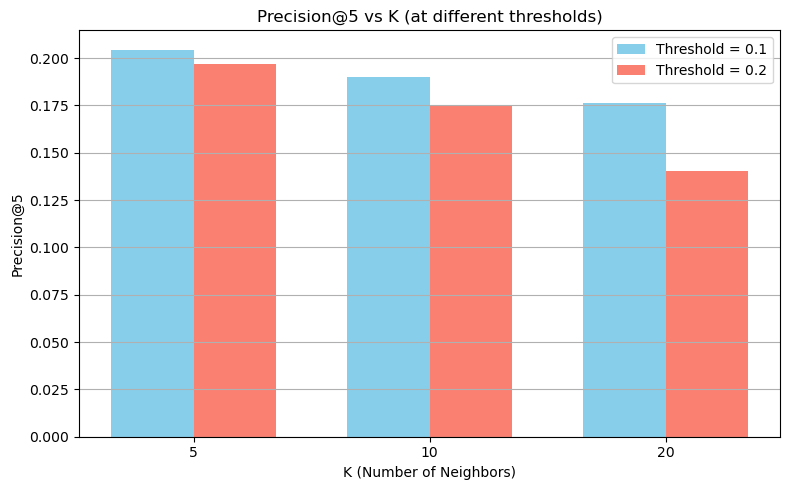

In [50]:
K_values = [5, 10, 20]
precision_thresh_01 = [0.2044, 0.1900, 0.1764]
precision_thresh_02 = [0.1967, 0.1744, 0.1403]

x = np.arange(len(K_values))  # label locations
width = 0.35  # width of the bars

# Plotting
plt.figure(figsize=(8, 5))
plt.bar(x - width/2, precision_thresh_01, width, label='Threshold = 0.1', color='skyblue')
plt.bar(x + width/2, precision_thresh_02, width, label='Threshold = 0.2', color='salmon')

# Labels and formatting
plt.title('Precision@5 vs K (at different thresholds)')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Precision@5')
plt.xticks(x, K_values)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()



### Content based filtering

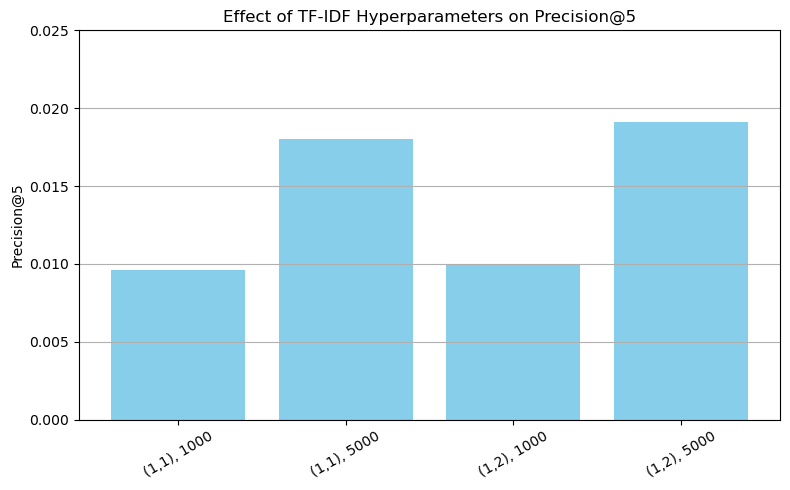

In [48]:
labels = [
    "(1,1), 1000", "(1,1), 5000",
    "(1,2), 1000", "(1,2), 5000"
]
precisions = [0.0096, 0.0180, 0.0100, 0.0191]

plt.figure(figsize=(8, 5))
plt.bar(labels, precisions, color='skyblue')
plt.ylabel("Precision@5")
plt.title("Effect of TF-IDF Hyperparameters on Precision@5")
plt.xticks(rotation=30)
plt.ylim(0, 0.025)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


## 3. Run Multiple Configurations

### a. user-user CF

In [63]:
# 1. Create the interaction matrix as a sparse matrix (efficient memory handling)
interaction_matrix = csr_matrix((ratings_df['ratings'], 
                                (ratings_df['user_id'], ratings_df['book_idx'])))

# 2. Define precision_at_k function
def precision_at_k(recommended_books, actual_books, K):
    recommended_books_set = set(recommended_books[:K])
    actual_books_set = set(actual_books)
    intersection = recommended_books_set.intersection(actual_books_set)
    return len(intersection) / K if K > 0 else 0

# 3. Function to perform User-User Collaborative Filtering
def user_user_collaborative_filtering(K, metric):
    # Initialize NearestNeighbors with sparse matrix support
    model = NearestNeighbors(n_neighbors=K, metric=metric, algorithm='brute', n_jobs=-1)
    model.fit(interaction_matrix)  # Fitting on the interaction matrix (sparse)
    return model

# 4. Hyperparameter Grid for tuning
user_user_params = {
    'n_neighbors': [5, 10, 20],
    'metric': ['cosine', 'euclidean']
}

# 5. Grid Search with Manual Loop for Hyperparameter Tuning
results = []

# 6. Tuning User-User Collaborative Filtering
for K in user_user_params['n_neighbors']:
    for metric in user_user_params['metric']:
        print(f"Running User-User CF with K={K}, Metric={metric}")
        model = user_user_collaborative_filtering(K, metric)
        
        # 7. Evaluate the model using precision at K for a set of users
        precisions = []
        for user in tqdm(ratings_df['user_id'].unique()):
            # Get the user row from the interaction matrix
            user_ratings = interaction_matrix[user, :].reshape(1, -1)  # Get the user row
            
            # Get the actual books that the user has rated
            actual_books = ratings_df[ratings_df['user_id'] == user]['book_idx'].values
            
            # Find the nearest neighbors for the current user
            recommended_books = model.kneighbors(user_ratings, return_distance=False)
            
            # Calculate precision at K
            precision = precision_at_k(recommended_books[0], actual_books, K)
            precisions.append(precision)
        
        avg_precision = np.mean(precisions)
        results.append(('User-User CF', K, metric, avg_precision))

# 8. Convert results to DataFrame for comparison
results_df = pd.DataFrame(results, columns=['Model', 'Param 1', 'Param 2', 'Avg Precision'])
print("\nResults Comparison Table:")
print(results_df)

# 9. Sort results by Avg Precision
results_df_sorted = results_df.sort_values(by='Avg Precision', ascending=False)
print("\nSorted Results by Avg Precision:")
print(results_df_sorted)

Running User-User CF with K=5, Metric=cosine


100%|██████████████████████████████████████████████████████████████████████████| 77805/77805 [1:30:20<00:00, 14.35it/s]


Running User-User CF with K=5, Metric=euclidean


100%|██████████████████████████████████████████████████████████████████████████| 77805/77805 [1:28:15<00:00, 14.69it/s]


Running User-User CF with K=10, Metric=cosine


...

Running User-User CF with K=20, Metric=cosine


100%|██████████████████████████████████████████████████████████████████████████| 77805/77805 [1:40:24<00:00, 12.92it/s]


Running User-User CF with K=20, Metric=euclidean


100%|██████████████████████████████████████████████████████████████████████████| 77805/77805 [1:16:27<00:00, 16.96it/s]



Results Comparison Table:
          Model  Param 1    Param 2  Avg Precision
0  User-User CF        5     cosine       0.000021
1  User-User CF        5  euclidean       0.000005
2  User-User CF       10     cosine       0.000018
3  User-User CF       10  euclidean       0.000012
4  User-User CF       20     cosine       0.000022
5  User-User CF       20  euclidean       0.000013

Sorted Results by Avg Precision:
          Model  Param 1    Param 2  Avg Precision
4  User-User CF       20     cosine       0.000022
0  User-User CF        5     cosine       0.000021
2  User-User CF       10     cosine       0.000018
5  User-User CF       20  euclidean       0.000013
3  User-User CF       10  euclidean       0.000012
1  User-User CF        5  euclidean       0.000005


### b. Item-Item CF

In [80]:
# --- PRECISION@K ---
def precision_at_k(pred_indices, true_indices, k):
    if len(true_indices) == 0:
        return 0
    hits = len(set(pred_indices[:k]) & set(true_indices))
    return hits / k

# --- COSINE SIMILARITY ---
def compute_item_item_similarity(rating_matrix):
    return cosine_similarity(rating_matrix.T, rating_matrix.T)

# --- COLLABORATIVE FILTERING CLASS ---
class ItemItemCF(BaseEstimator):
    def __init__(self, min_rating=1, similarity='cosine', k=5):
        self.min_rating = min_rating
        self.similarity = similarity
        self.k = k

    def fit(self, X, y=None):
        self.train_data = X
        self.users = X['user_id'].unique()
        self.books = X['book_id'].unique()
        
        # Create book-id to index mappings
        self.book_id_to_index = {bid: idx for idx, bid in enumerate(self.books)}
        
        # Create user-id to index mappings
        self.user_id_to_index = {uid: idx for idx, uid in enumerate(self.users)}

        # Create the rating matrix
        self.rating_matrix = np.zeros((len(self.users), len(self.books)))
        for _, row in X.iterrows():
            user_idx = self.user_id_to_index[row['user_id']]
            book_idx = self.book_id_to_index[row['book_id']]
            self.rating_matrix[user_idx, book_idx] = row['ratings']

        # Compute similarity
        if self.similarity == 'cosine':
            self.item_sim = compute_item_item_similarity(self.rating_matrix)
        elif self.similarity == 'pearson':
            self.item_sim = np.corrcoef(self.rating_matrix, rowvar=False)
        
        return self

    def predict(self, X):
        precisions = []

        for user in tqdm(X['user_id'].unique(), desc="Evaluating users"):
            rated_books = X[X['user_id'] == user]['book_id'].values
            actual_books = X[X['user_id'] == user]['book_id'].values

            rated_indices = [self.book_id_to_index[b] for b in rated_books if b in self.book_id_to_index]
            actual_indices = [self.book_id_to_index[b] for b in actual_books if b in self.book_id_to_index]

            if not rated_indices or not actual_indices:
                continue

            # Get similarity scores for each rated book
            sim_scores = self.item_sim[rated_indices].mean(axis=0)
            sim_scores[rated_indices] = -np.inf  # Avoid recommending already rated books

            # Get top k recommended books
            top_indices = np.argsort(-sim_scores)[:self.k]
            precision = precision_at_k(top_indices, actual_indices, self.k)
            precisions.append(precision)

        return np.mean(precisions)


# --- SPLIT DATA ---
books_df = books_df.head(40000)  # Truncating data for example
interactions_df = ratings_df.head(40000)

train, test = train_test_split(interactions_df, test_size=0.2, random_state=42)

# --- SETUP PARAMETER GRID ---
param_grid = {
    'min_rating': [1, 3],
    'similarity': ['cosine', 'pearson'],
    'k': [5]
}

# --- GRIDSEARCH ---
cf_model = ItemItemCF()
grid_search = GridSearchCV(cf_model, param_grid, cv=3, scoring='neg_mean_squared_error', verbose=1)

grid_search.fit(train)

# --- FINAL RESULTS ---
print("\nBest Parameters:")
print(grid_search.best_params_)
print(f"Best Score: {grid_search.best_score_}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits

Best Parameters:
{'k': 5, 'min_rating': 1, 'similarity': 'cosine'}
Best Score: nan


### c. Content Based Filtering

In [69]:
# --------------------- 3. Precision@K ---------------------
def precision_at_k(pred_indices, true_indices, k=5):
    if len(true_indices) == 0:
        return 0
    hits = len(set(pred_indices[:k]) & set(true_indices))
    return hits / k

# --------------------- 4. Evaluate one config ---------------------
def evaluate_content_based(books_df, ratings_df, ngram_range, max_features, min_df, max_df):
    tfidf, tfidf_matrix = vectorize_books(books_df, ngram_range, max_features, min_df, max_df)
    item_sim = cosine_similarity(tfidf_matrix, tfidf_matrix, dense_output=False)

    train, test = train_test_split(ratings_df, test_size=0.2, random_state=42)

    book_id_to_index = {bid: idx for idx, bid in enumerate(books_df['book_id'].values)}

    precisions = []

    for user in tqdm(train['user_id'].unique(), desc="Evaluating users", leave=False):
        rated_books = train[train['user_id'] == user]['book_id'].values
        actual_books = test[test['user_id'] == user]['book_id'].values

        rated_indices = [book_id_to_index[b] for b in rated_books if b in book_id_to_index]
        actual_indices = [book_id_to_index[b] for b in actual_books if b in book_id_to_index]

        if not rated_indices or not actual_indices:
            continue

        sim_scores = item_sim[rated_indices].mean(axis=0).A1
        sim_scores[rated_indices] = -np.inf

        top_indices = np.argsort(-sim_scores)[:5]
        prec = precision_at_k(top_indices, actual_indices)
        precisions.append(prec)

    return np.mean(precisions)

# --------------------- 5. Define grid search params ---------------------
param_grid = {
    "ngram_range": [(1, 1), (1, 2)],
    "max_features": [1000, 3000],
    "min_df": [2],
    "max_df": [0.8, 0.9]
}

# --------------------- 6. Prepare data ---------------------
books_df = books_df.head(30000)
ratings_df = ratings_df.head(30000)

books_df = create_combined_column(books_df)

# --------------------- 7. Perform grid search ---------------------
results = []
best_score = -1
best_config = {}

combinations = list(product(
    param_grid["ngram_range"],
    param_grid["max_features"],
    param_grid["min_df"],
    param_grid["max_df"]
))

for ngram_range, max_features, min_df, max_df in combinations:
    print(f"\nTrying: ngram={ngram_range}, max_features={max_features}, min_df={min_df}, max_df={max_df}")

    try:
        score = evaluate_content_based(
            books_df, ratings_df,
            ngram_range=ngram_range,
            max_features=max_features,
            min_df=min_df,
            max_df=max_df
        )

        print(f"→ Precision@5: {score:.4f}")

        results.append({
            "ngram_range": ngram_range,
            "max_features": max_features,
            "min_df": min_df,
            "max_df": max_df,
            "precision@5": score
        })

        if score > best_score:
            best_score = score
            best_config = {
                "ngram_range": ngram_range,
                "max_features": max_features,
                "min_df": min_df,
                "max_df": max_df
            }

    except Exception as e:
        print("Error:", e)

# --------------------- 8. Store comparison table ---------------------
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="precision@5", ascending=False)

print("\nGrid Search Results Table:")
print(results_df)

print("\n Best Config Found:")
print(best_config)
print(f"Best Precision@5: {best_score:.4f}")


Trying: ngram=(1, 1), max_features=1000, min_df=2, max_df=0.8


→ Precision@5: 0.0096

Trying: ngram=(1, 1), max_features=1000, min_df=2, max_df=0.9


→ Precision@5: 0.0096

Trying: ngram=(1, 1), max_features=3000, min_df=2, max_df=0.8


→ Precision@5: 0.0162

Trying: ngram=(1, 1), max_features=3000, min_df=2, max_df=0.9


→ Precision@5: 0.0162

Trying: ngram=(1, 2), max_features=1000, min_df=2, max_df=0.8


→ Precision@5: 0.0100

Trying: ngram=(1, 2), max_features=1000, min_df=2, max_df=0.9


→ Precision@5: 0.0100

Trying: ngram=(1, 2), max_features=3000, min_df=2, max_df=0.8


→ Precision@5: 0.0153

Trying: ngram=(1, 2), max_features=3000, min_df=2, max_df=0.9


→ Precision@5: 0.0153

Grid Search Results Table:
  ngram_range  max_features  min_df  max_df  precision@5
2      (1, 1)          3000       2     0.8     0.016222
3      (1, 1)          3000       2     0.9     0.016222
6      (1, 2)          3000       2     0.8     0.015333
7      (1, 2)          3000       2     0.9     0.015333
4      (1, 2)          1000       2     0.8     0.010000
5      (1, 2)          1000       2     0.9     0.010000
0      (1, 1)          1000       2     0.8     0.009556
1      (1, 1)          1000       2     0.9     0.009556

 Best Config Found:
{'ngram_range': (1, 1), 'max_features': 3000, 'min_df': 2, 'max_df': 0.8}
Best Precision@5: 0.0162


### Saving User-User Collaborative Filtering Model

In [ ]:
import pickle
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors

# --- User-User CF Model with KNN --- 

def user_user_cf_knn(train, k=5, similarity='cosine'):
    # Create a mapping of user_ids to indices for the rating matrix
    user_id_to_index = {user_id: idx for idx, user_id in enumerate(train['user_id'].unique())}
    book_id_to_index = {book_id: idx for idx, book_id in enumerate(books_df['book_id'])}  # No .values()

    # Initialize rating matrix with zeros
    rating_matrix = np.zeros((len(user_id_to_index), len(books_df)))

    for i, row in train.iterrows():
        user_idx = user_id_to_index.get(row['user_id'], -1)
        book_idx = book_id_to_index.get(row['book_id'], -1)

        # Check if both indices are valid
        if user_idx != -1 and book_idx != -1:
            rating_matrix[user_idx, book_idx] = row['ratings']

    # Use NearestNeighbors from sklearn to find the nearest neighbors
    nn = NearestNeighbors(n_neighbors=k, metric=similarity)
    nn.fit(rating_matrix)
    
    return nn

# Save User-User CF model with KNN
train, test = train_test_split(ratings_df, test_size=0.2, random_state=42)
user_sim_knn = user_user_cf_knn(train, k=5, similarity='cosine')

# Save the model using pickle
with open('user_user_cf_knn_model.pkl', 'wb') as file:
    pickle.dump(user_sim_knn, file)


### Saving Item-Item Collaborative Filtering Model

In [89]:
# --- Item-Item CF Model with KNN --- 

def item_item_cf_knn(train, k=5, similarity='cosine'):
    # Create a mapping of user_ids to indices for the rating matrix
    user_id_to_index = {user_id: idx for idx, user_id in enumerate(train['user_id'].unique())}
    book_id_to_index = {book_id: idx for idx, book_id in enumerate(books_df['book_id'])}  # Corrected this line

    # Initialize rating matrix with zeros
    rating_matrix = np.zeros((len(user_id_to_index), len(books_df)))

    for i, row in train.iterrows():
        user_idx = user_id_to_index.get(row['user_id'], -1)
        book_idx = book_id_to_index.get(row['book_id'], -1)

        # Check if both indices are valid
        if user_idx != -1 and book_idx != -1:
            rating_matrix[user_idx, book_idx] = row['ratings']

    # Use NearestNeighbors from sklearn to find the nearest items
    nn = NearestNeighbors(n_neighbors=k, metric=similarity)
    nn.fit(rating_matrix.T)  # Transpose to make it item-item similarity
    
    return nn

# Save Item-Item CF model with KNN
item_sim_knn = item_item_cf_knn(train, k=5, similarity='cosine')

# Save the model using pickle
with open('item_item_cf_knn_model.pkl', 'wb') as file:
    pickle.dump(item_sim_knn, file)


### Saving Content-Based Model

In [91]:
# --- Content-Based Model using Book Descriptions --- 

def content_based_model(books_df, interactions_df, ngram_range=(1, 1), max_features=3000, min_df=2, max_df=0.8):
    # Content-based filtering using text features (book descriptions)
    vectorizer = CountVectorizer(ngram_range=ngram_range, max_features=max_features, min_df=min_df, max_df=max_df)
    book_descriptions = books_df['combined'].fillna('')  # Assuming books_df has a 'description' column
    X = vectorizer.fit_transform(book_descriptions)

    # Nearest Neighbors for Content-based Recommendations
    knn = NearestNeighbors(n_neighbors=5, metric='cosine')
    knn.fit(X)
    
    return knn, vectorizer

# Train Content-Based Model
cb_model, vectorizer = content_based_model(books_df, ratings_df, ngram_range=(1, 1), max_features=3000, min_df=2, max_df=0.8)

# Save Content-Based model and vectorizer
with open('content_based_model.pkl', 'wb') as file:
    pickle.dump(cb_model, file)

with open('vectorizer.pkl', 'wb') as file:
    pickle.dump(vectorizer, file)


In [2]:
# Content-Based CF Prediction Function
def content_based_predict(book_id, model, books_df, ratings_df, k=5):
    book_idx = books_df[books_df['book_id'] == book_id].index[0]
    book_desc = books_df.loc[book_idx, 'combined']
    book_vector = vectorizer.transform([book_desc])
    distances, indices = model.kneighbors(book_vector, n_neighbors=k)
    neighbor_ratings = []
    for idx in indices[0]:
        similar_book_id = books_df.iloc[idx]['book_id']
        rating = ratings_df[(ratings_df['book_id'] == similar_book_id) & (ratings_df['user_id'] == user_id)]['ratings']
        if len(rating) > 0:
            neighbor_ratings.append(rating.values[0])
    return np.mean(neighbor_ratings)